In [2]:
import os
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Unavailable'}")

# Rutas
BASE_DIR  = "chest_xray"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR  = os.path.join(BASE_DIR, "test")
VAL_DIR   = os.path.join(BASE_DIR, "val")

using: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


In [3]:
VALID_EXTENSIONS = (".jpeg",)

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

class ChestXRayDataset(Dataset):
    def __init__(self, directory, transform=None):
        self.transform = transform
        self.images = []
        self.labels = []
        self.classes = {"NORMAL": 0, "PNEUMONIA": 1}
        
        for clase, idx in self.classes.items():
            folder = os.path.join(directory, clase)
            files = [f for f in os.listdir(folder) 
                       if f.lower().endswith(VALID_EXTENSIONS)]
            for file in files:
                self.images.append(os.path.join(folder, file))
                self.labels.append(idx)
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

train_dataset = ChestXRayDataset(TRAIN_DIR, transform=train_transforms)
val_dataset   = ChestXRayDataset(VAL_DIR, transform=test_transforms)
test_dataset  = ChestXRayDataset(TEST_DIR, transform=test_transforms)

# Join train + val
train_dataset = torch.utils.data.ConcatDataset([train_dataset, val_dataset])

print(f"Train: {len(train_dataset)} images")
print(f"Test:  {len(test_dataset)} images")

Train: 5232 images
Test:  624 images


In [4]:
def calculate_weights(dataset):
    labels = []
    for d in dataset.datasets:
        labels.extend(d.labels)
    labels = np.array(labels)
    
    classes, counts = np.unique(labels, return_counts=True)
    class_weights = 1.0 / counts
    sample_weights = class_weights[labels]
    return torch.FloatTensor(sample_weights)

weights = calculate_weights(train_dataset)
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False,   num_workers=0)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 164
Test batches: 20


In [5]:
def build_model():
    # Load pre-trained DenseNet121 in ImageNet
    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
    
    # Freeze all layers so we don't modify the knowledge
    for param in model.parameters():
        param.requires_grad = False
    
    # Replace original classifier (1000 classes) for ours (2 classes)
    num_features = model.classifier.in_features  # 1024 output features in DenseNet
    model.classifier = nn.Sequential(
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, 2)  # 2 classes: NORMAL y PNEUMONIA
    )
    
    return model.to(device)

model = build_model()

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = total - trainable

print(f"Total parameters:      {total:,}")
print(f"Trainable parameters:  {trainable:,}")
print(f"Frozen parameters:   {frozen:,}")

Total parameters:      7,216,770
Trainable parameters:  262,914
Frozen parameters:   6,953,856


In [6]:
def train_model(model, train_loader, test_loader, epochs=15, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), 
        lr=lr
    )
    
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    
    for epoch in range(epochs):
    
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()           # clean previous gradients
            outputs = model(images)         # forward pass
            loss = criterion(outputs, labels)  # Compute loss
            loss.backward()                 # backpropagation
            optimizer.step()               # update weights
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            train_correct += (predicted == labels).sum().item()
            train_total += labels.size(0)
        
        # Validation

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)
        
        history["train_loss"].append(train_loss / len(train_loader))
        history["train_acc"].append(train_correct / train_total)
        history["val_loss"].append(val_loss / len(test_loader))
        history["val_acc"].append(val_correct / val_total)
        
        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {history['train_loss'][-1]:.4f} | "
              f"Train Acc: {history['train_acc'][-1]:.4f} | "
              f"Val Loss: {history['val_loss'][-1]:.4f} | "
              f"Val Acc: {history['val_acc'][-1]:.4f}")
    
    return history

print("Phase 1 — Feature extraction")
history_phase1 = train_model(model, train_loader, test_loader, epochs=15, lr=1e-3)

Phase 1 — Feature extraction
Epoch 01/15 | Train Loss: 0.2800 | Train Acc: 0.8844 | Val Loss: 0.3457 | Val Acc: 0.8446
Epoch 02/15 | Train Loss: 0.2278 | Train Acc: 0.9084 | Val Loss: 0.2883 | Val Acc: 0.8782
Epoch 03/15 | Train Loss: 0.1684 | Train Acc: 0.9348 | Val Loss: 0.3209 | Val Acc: 0.8718
Epoch 04/15 | Train Loss: 0.1664 | Train Acc: 0.9343 | Val Loss: 0.3138 | Val Acc: 0.8766
Epoch 05/15 | Train Loss: 0.1670 | Train Acc: 0.9352 | Val Loss: 0.3246 | Val Acc: 0.8638
Epoch 06/15 | Train Loss: 0.1674 | Train Acc: 0.9367 | Val Loss: 0.3035 | Val Acc: 0.8798
Epoch 07/15 | Train Loss: 0.1713 | Train Acc: 0.9352 | Val Loss: 0.3432 | Val Acc: 0.8606
Epoch 08/15 | Train Loss: 0.1814 | Train Acc: 0.9329 | Val Loss: 0.4040 | Val Acc: 0.8285
Epoch 09/15 | Train Loss: 0.1619 | Train Acc: 0.9371 | Val Loss: 0.2747 | Val Acc: 0.8846
Epoch 10/15 | Train Loss: 0.1697 | Train Acc: 0.9327 | Val Loss: 0.3005 | Val Acc: 0.8766
Epoch 11/15 | Train Loss: 0.1600 | Train Acc: 0.9364 | Val Loss: 0.3420

In [7]:
def unfreeze_last_block(model):
    # Defrost the last dense block and final norm from DenseNet121

    for name, param in model.named_parameters():
        if "denseblock4" in name or "norm5" in name or "classifier" in name:
            param.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters after defrost: {trainable:,}")

unfreeze_last_block(model)

print("\nPhase 2 — Fine-tuning")
history_phase2 = train_model(model, train_loader, test_loader, epochs=10, lr=1e-5)

Trainable parameters after defrost: 2,423,042

Phase 2 — Fine-tuning
Epoch 01/10 | Train Loss: 0.1191 | Train Acc: 0.9547 | Val Loss: 0.2775 | Val Acc: 0.8830
Epoch 02/10 | Train Loss: 0.1067 | Train Acc: 0.9614 | Val Loss: 0.2830 | Val Acc: 0.8862
Epoch 03/10 | Train Loss: 0.0988 | Train Acc: 0.9618 | Val Loss: 0.3034 | Val Acc: 0.8894
Epoch 04/10 | Train Loss: 0.0992 | Train Acc: 0.9631 | Val Loss: 0.2962 | Val Acc: 0.8814
Epoch 05/10 | Train Loss: 0.0866 | Train Acc: 0.9711 | Val Loss: 0.3350 | Val Acc: 0.8862
Epoch 06/10 | Train Loss: 0.0784 | Train Acc: 0.9698 | Val Loss: 0.3543 | Val Acc: 0.8846
Epoch 07/10 | Train Loss: 0.0790 | Train Acc: 0.9700 | Val Loss: 0.3358 | Val Acc: 0.8846
Epoch 08/10 | Train Loss: 0.0874 | Train Acc: 0.9685 | Val Loss: 0.3405 | Val Acc: 0.8782
Epoch 09/10 | Train Loss: 0.0788 | Train Acc: 0.9704 | Val Loss: 0.3101 | Val Acc: 0.8894
Epoch 10/10 | Train Loss: 0.0703 | Train Acc: 0.9761 | Val Loss: 0.3397 | Val Acc: 0.8846


DenseNet121 Final Evaluation
              precision    recall  f1-score   support

      NORMAL       0.95      0.74      0.83       234
   PNEUMONIA       0.86      0.97      0.91       390

    accuracy                           0.88       624
   macro avg       0.90      0.85      0.87       624
weighted avg       0.89      0.88      0.88       624



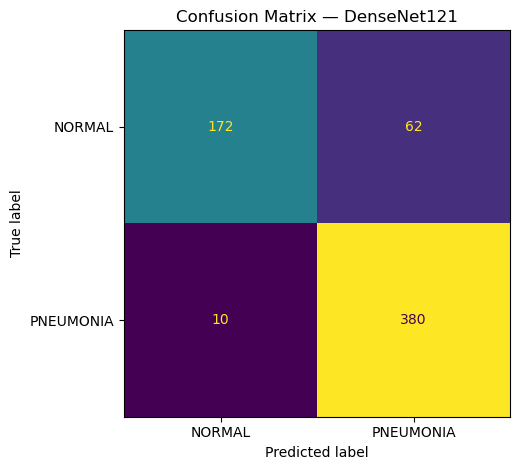

In [8]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print("DenseNet121 Final Evaluation")
print(classification_report(all_labels, all_preds, target_names=["NORMAL", "PNEUMONIA"]))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["NORMAL", "PNEUMONIA"])
disp.plot(colorbar=False)
plt.title("Confusion Matrix — DenseNet121")
plt.tight_layout()
plt.show()